# Práctica: Extracción de Indicadores Económicos
## Indicador: GDP per Capita (Banco Mundial / Our World in Data)

**Materia:** Tópicos de Big Data  
**Fuente:** World Bank vía Our World in Data (OWID)  
**Propósito:** Extraer, limpiar, estructurar y analizar la serie temporal del Producto Interno Bruto (PIB) per cápita en dólares internacionales constantes (PPA).

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

### 1. Extracción del Dataset desde Our World in Data

In [2]:
# Carga del indicador: GDP per capita
df_gdp = pd.read_csv(
    "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

### 2. Exploración Inicial de los Datos

In [3]:
df_gdp.head(5)

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [4]:
df_gdp.shape

(7445, 5)

In [5]:
df_gdp.columns.tolist()

['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region']

In [6]:
df_gdp.dtypes

entity                   str
code                     str
year                   int64
ny_gdp_pcap_pp_kd    float64
owid_region              str
dtype: object

In [7]:
df_gdp.tail()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
7440,Zimbabwe,ZWE,2021,4827.1094,Africa
7441,Zimbabwe,ZWE,2022,5036.7830,Africa
7442,Zimbabwe,ZWE,2023,5218.0454,Africa
7443,Zimbabwe,ZWE,2024,5211.8975,Africa
7444,Zimbabwe,ZWE,2025,5529.2330,Africa


### 3. Transformación y Renombrado de Columnas

In [8]:
# Renombrar columnas
df_gdp.rename(columns={
    'entity': 'Pais',
    'code': 'Codigo',
    'year': 'Anio',
    'ny_gdp_pcap_pp_kd': 'PIB_Per_Capita',
    'owid_region': 'Region'
}, inplace=True)

df_gdp.head(3)

,Pais,Codigo,Anio,PIB_Per_Capita,Region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia


In [9]:
# Revisión de valores nulos
df_gdp.isnull().sum()

Pais                0
Codigo              0
Anio                0
PIB_Per_Capita      0
Region            468
dtype: int64

### 4. Filtrado y Análisis de México (2000 a 2023)

In [10]:
mexico_gdp = df_gdp[(df_gdp['Pais'] == 'Mexico') & (df_gdp['Anio'] >= 2000)]
mexico_gdp.head(10)

,Pais,Codigo,Anio,PIB_Per_Capita,Region
4333,Mexico,MEX,2000,20470.494,North America
4334,Mexico,MEX,2001,20078.219,North America
4335,Mexico,MEX,2002,19744.793,North America
4336,Mexico,MEX,2003,19701.463,North America
4337,Mexico,MEX,2004,20127.225,North America
4338,Mexico,MEX,2005,20277.256,North America
4339,Mexico,MEX,2006,20965.826,North America
4340,Mexico,MEX,2007,21102.270,North America
4341,Mexico,MEX,2008,20992.560,North America
4342,Mexico,MEX,2009,19385.543,North America


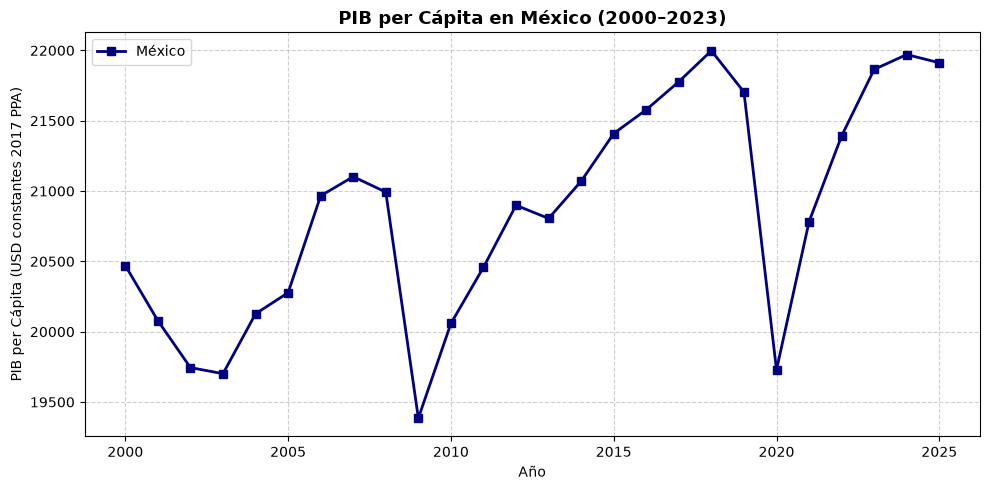

In [11]:
# Graficar PIB per cápita de México
plt.figure(figsize=(10, 5))
plt.plot(mexico_gdp['Anio'], mexico_gdp['PIB_Per_Capita'], marker='s', color='navy', linewidth=2, label='México')
plt.title('PIB per Cápita en México (2000–2023)', fontsize=13, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('PIB per Cápita (USD constantes 2017 PPA)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Comparación Internacional de PIB per Cápita (2000–2023)

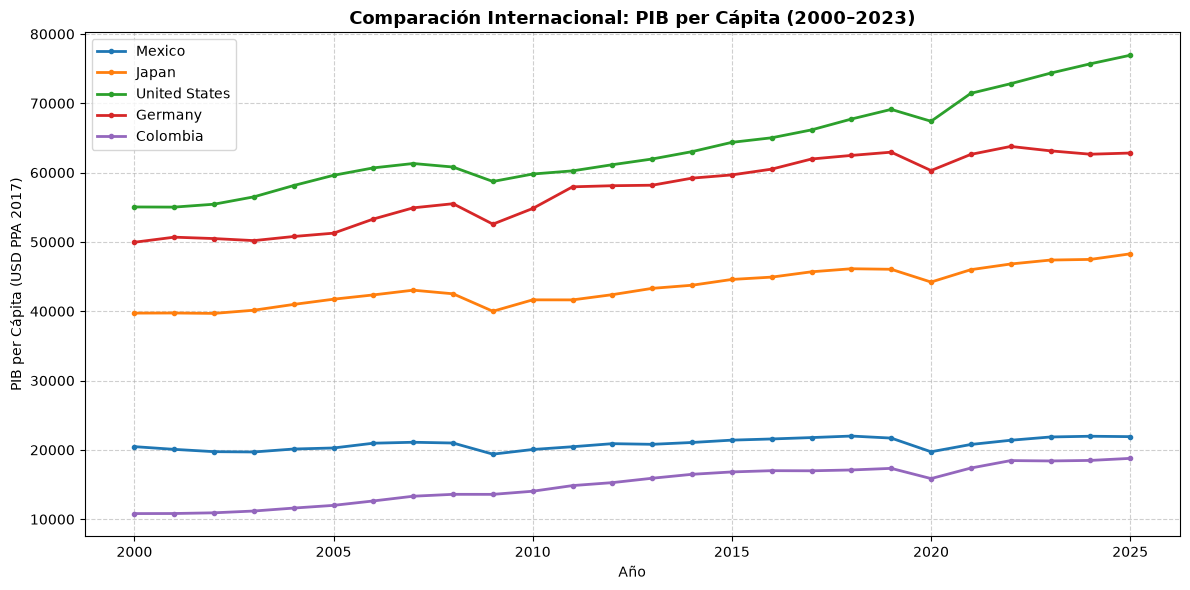

In [12]:
paises_comp = ['Mexico', 'Japan', 'United States', 'Germany', 'Colombia']
df_comp_gdp = df_gdp[(df_gdp['Pais'].isin(paises_comp)) & (df_gdp['Anio'] >= 2000)]

plt.figure(figsize=(12, 6))
for pais in paises_comp:
    sub = df_comp_gdp[df_comp_gdp['Pais'] == pais]
    plt.plot(sub['Anio'], sub['PIB_Per_Capita'], marker='.', label=pais, linewidth=2)

plt.title('Comparación Internacional: PIB per Cápita (2000–2023)', fontsize=13, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('PIB per Cápita (USD PPA 2017)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 6. Top 10 Países con Mayor PIB per Cápita en 2023

In [13]:
top_gdp_2023 = (
    df_gdp[(df_gdp['Anio'] == 2023) & (df_gdp['Codigo'].notnull())]
    .sort_values(by='PIB_Per_Capita', ascending=False)
    .head(10)
)
top_gdp_2023[['Pais', 'Codigo', 'PIB_Per_Capita', 'Region']]

,Pais,Codigo,PIB_Per_Capita,Region
6023,Singapore,SGP,130296.84,Asia
3960,Luxembourg,LUX,130048.92,Europe
3187,Ireland,IRL,117659.73,Europe
5497,Qatar,QAT,116159.14,Asia
3996,Macao,MAC,104815.20,Asia
740,Bermuda,BMU,102268.92,North America
5033,Norway,NOR,94364.96,Europe
6543,Switzerland,CHE,85383.36,Europe
1227,Cayman Islands,CYM,79580.89,North America
955,Brunei,BRN,76616.70,Asia
